### Setup

In [1]:
import os
cwd = os.getcwd()
CODE_FOLDER = "/zeeguu-api/"
CODE_ROOT_FOLDER = cwd + CODE_FOLDER

from git import Repo
if not os.path.exists(CODE_ROOT_FOLDER):
    Repo.clone_from("https://github.com/zeeguu/api", CODE_ROOT_FOLDER)

# Deployment View
To get information about the deployment of the system, we need to look at completely different types of files than the ones we have been looking at so far. Instead of looking at the source code files, we need to look at deployment-related files and configurations. For example, we can look at docker compose files to see what services are defined, what images they use, and how they are connected to each other. 

We could also look at docker files to see how the images are built and what dependencies they have. The github workflow files could also provide insights into the deployment process and how the application is built and deployed. And taking a look at the scripts used for deployment would also be useful to understand the deployment process and how the application is deployed in different environments. 
However, to limit the scope of my analysis, i have choosen to focus on the docker compose files and the services they define.

## Discovery 
First we need to extract the relevant information. 
We must find the files relevant for deplyment and then analyse them to understand what they each do and how they interact with each other. 
As statet, we will focus on the docker compose files and the services they define.

In [2]:
import os 

#Helper function to get real path from relative path (e.g. for build contexts)
def resolve_path(path, location, base_folder=CODE_ROOT_FOLDER):
    if path.startswith("./") or path.startswith("../"):
        return resolve_path(os.path.normpath(os.path.join(location.parent, path)), location) # recursively resolve until we get an absolute path or a path that doesn't start with ./ or ../
    if path.startswith(".."):
        return str(location.parent)
    if path.startswith("."):
        return str(location)
    return str(path)

In [3]:
import yaml
from pathlib import Path


def discover_deployment_info(code_root_folder):
    # Define the information we will collect:
    compose_info = {
        "services": {}, 
        "networks": set(),
        "volumes": set(),
        "images": set(),
    }

    # Find all docker compose files in the code repository
    compose_files_yaml = Path(code_root_folder).rglob("*compose*.yaml") 
    compose_files_yml = Path(code_root_folder).rglob("*compose*.yml")
    compose_files = list(compose_files_yaml) + list(compose_files_yml)
    
    for cf in compose_files:
        #print(f"Processing docker compose file: {cf.relative_to(code_root_folder)}")
        try:
            content = yaml.safe_load(open(cf, 'r')) # load the content of the docker compose file as a python dictionary
            cf_filepath = cf.relative_to(code_root_folder)

            if not content:
                continue # if the file is empty or cannot be parsed, skip it

            # capture top-level networks: 
            for net in content["networks"].keys(): 
                    compose_info["networks"].add(net)
            
            # iterate over services and capture their information:
            for s_name, s_config in content["services"].items():
                #print(f"Found service: {s_name} in file: {cf.relative_to(code_root_folder)}")
                
                #networks for the service:
                networks = s_config.get('networks', [])
                for net in networks:
                    compose_info["networks"].add(net) 
            
                #volumes for the service 
                raw_volumes = s_config.get('volumes', [])
                clean_volumes = set()
                for vol in raw_volumes:
                    if isinstance(vol, str):
                        src = vol.split(':')[0] # Get the source part of the volume mapping (format: host_path:container_path)
                    elif isinstance(vol, dict) and 'source' in vol: # if using long syntax
                        src = vol.get('source', 'anonymous') # if no source key, use 'anonymous' as placeholder (e.g. for anonymous volumes)
                    src = resolve_path(src, cf_filepath, CODE_ROOT_FOLDER) # resolve the source path to an absolute path
                    clean_volumes.add(src)
                    compose_info["volumes"].add(src) # add the source of the volume to the top-level volumes set
                
                #build context for the service
                raw_builds = s_config.get('build', None)
                clean_builds = set()
                for build in raw_builds if isinstance(raw_builds, list) else [raw_builds]: # handle both single build and list of builds
                    if build:
                        if isinstance(build, dict) and "context" in build:
                            build = build["context"]
                        build = resolve_path(build, cf_filepath, CODE_ROOT_FOLDER) # resolve the build context path to an absolute path
                        clean_builds.add(build)    
                
                #info about the service:
                compose_info["services"][s_name] = {
                    "image": s_config.get("image", ""),
                    "build": clean_builds,
                    "depends_on": s_config.get("depends_on", []),
                    "ports": s_config.get("ports", []),
                    "is_dev": "dev" in s_name.lower() or "test" in s_name.lower(), # simple heuristic to determine if it's a dev/test service based on the name
                    "networks": networks,
                    "volumes": clean_volumes,
                }

        except Exception as e:
            print(f"Error processing file {cf}: {e}")

    return compose_info

deployment_info = discover_deployment_info(CODE_ROOT_FOLDER)
print("Deployment info:", deployment_info)

Deployment info: {'services': {'mysql': {'image': 'mysql:5.7', 'build': set(), 'depends_on': [], 'ports': ['3306:3306'], 'is_dev': False, 'networks': ['zeeguu_backend'], 'volumes': {'${ZEEGUU_DATA_FOLDER}/mysql'}}, 'fmd_mysql': {'image': 'mysql:5.7', 'build': set(), 'depends_on': [], 'ports': [], 'is_dev': False, 'networks': ['zeeguu_backend'], 'volumes': {'${ZEEGUU_DATA_FOLDER}/fmd_mysql'}}, 'elasticsearch_v8': {'image': 'elasticsearch:8.12.2', 'build': set(), 'depends_on': [], 'ports': [], 'is_dev': False, 'networks': ['zeeguu_backend'], 'volumes': {'${ZEEGUU_DATA_FOLDER}/elasticsearch/data'}}, 'readability_server': {'image': 'zeeguu/readability_server', 'build': set(), 'depends_on': [], 'ports': [], 'is_dev': False, 'networks': ['zeeguu_backend'], 'volumes': set()}, 'autoheal': {'image': 'willfarrell/autoheal', 'build': set(), 'depends_on': [], 'ports': [], 'is_dev': False, 'networks': [], 'volumes': {'/var/run/docker.sock'}}, 'embedding_api': {'image': 'zeeguu/semantic-emb-api:main

## Visualization of the deployment architecture
To visualize, we can create a graph where the nodes represent the different services defined in the docker compose files, and the edges represent the connections between the services (e.g. if one service depends on another service, there would be an edge from the dependent service to the service it depends on). We can also include information about the images used by each service, and any other relevant configuration details (e.g. environment variables, ports, volumes, etc.) as attributes of the nodes or edges in the graph. This visualization can help us understand the overall structure of the deployment architecture and how the different services interact with each other.

zsh:1: parse error near `-m'
Deployment architecture diagram saved as graphs/deployment_architecture


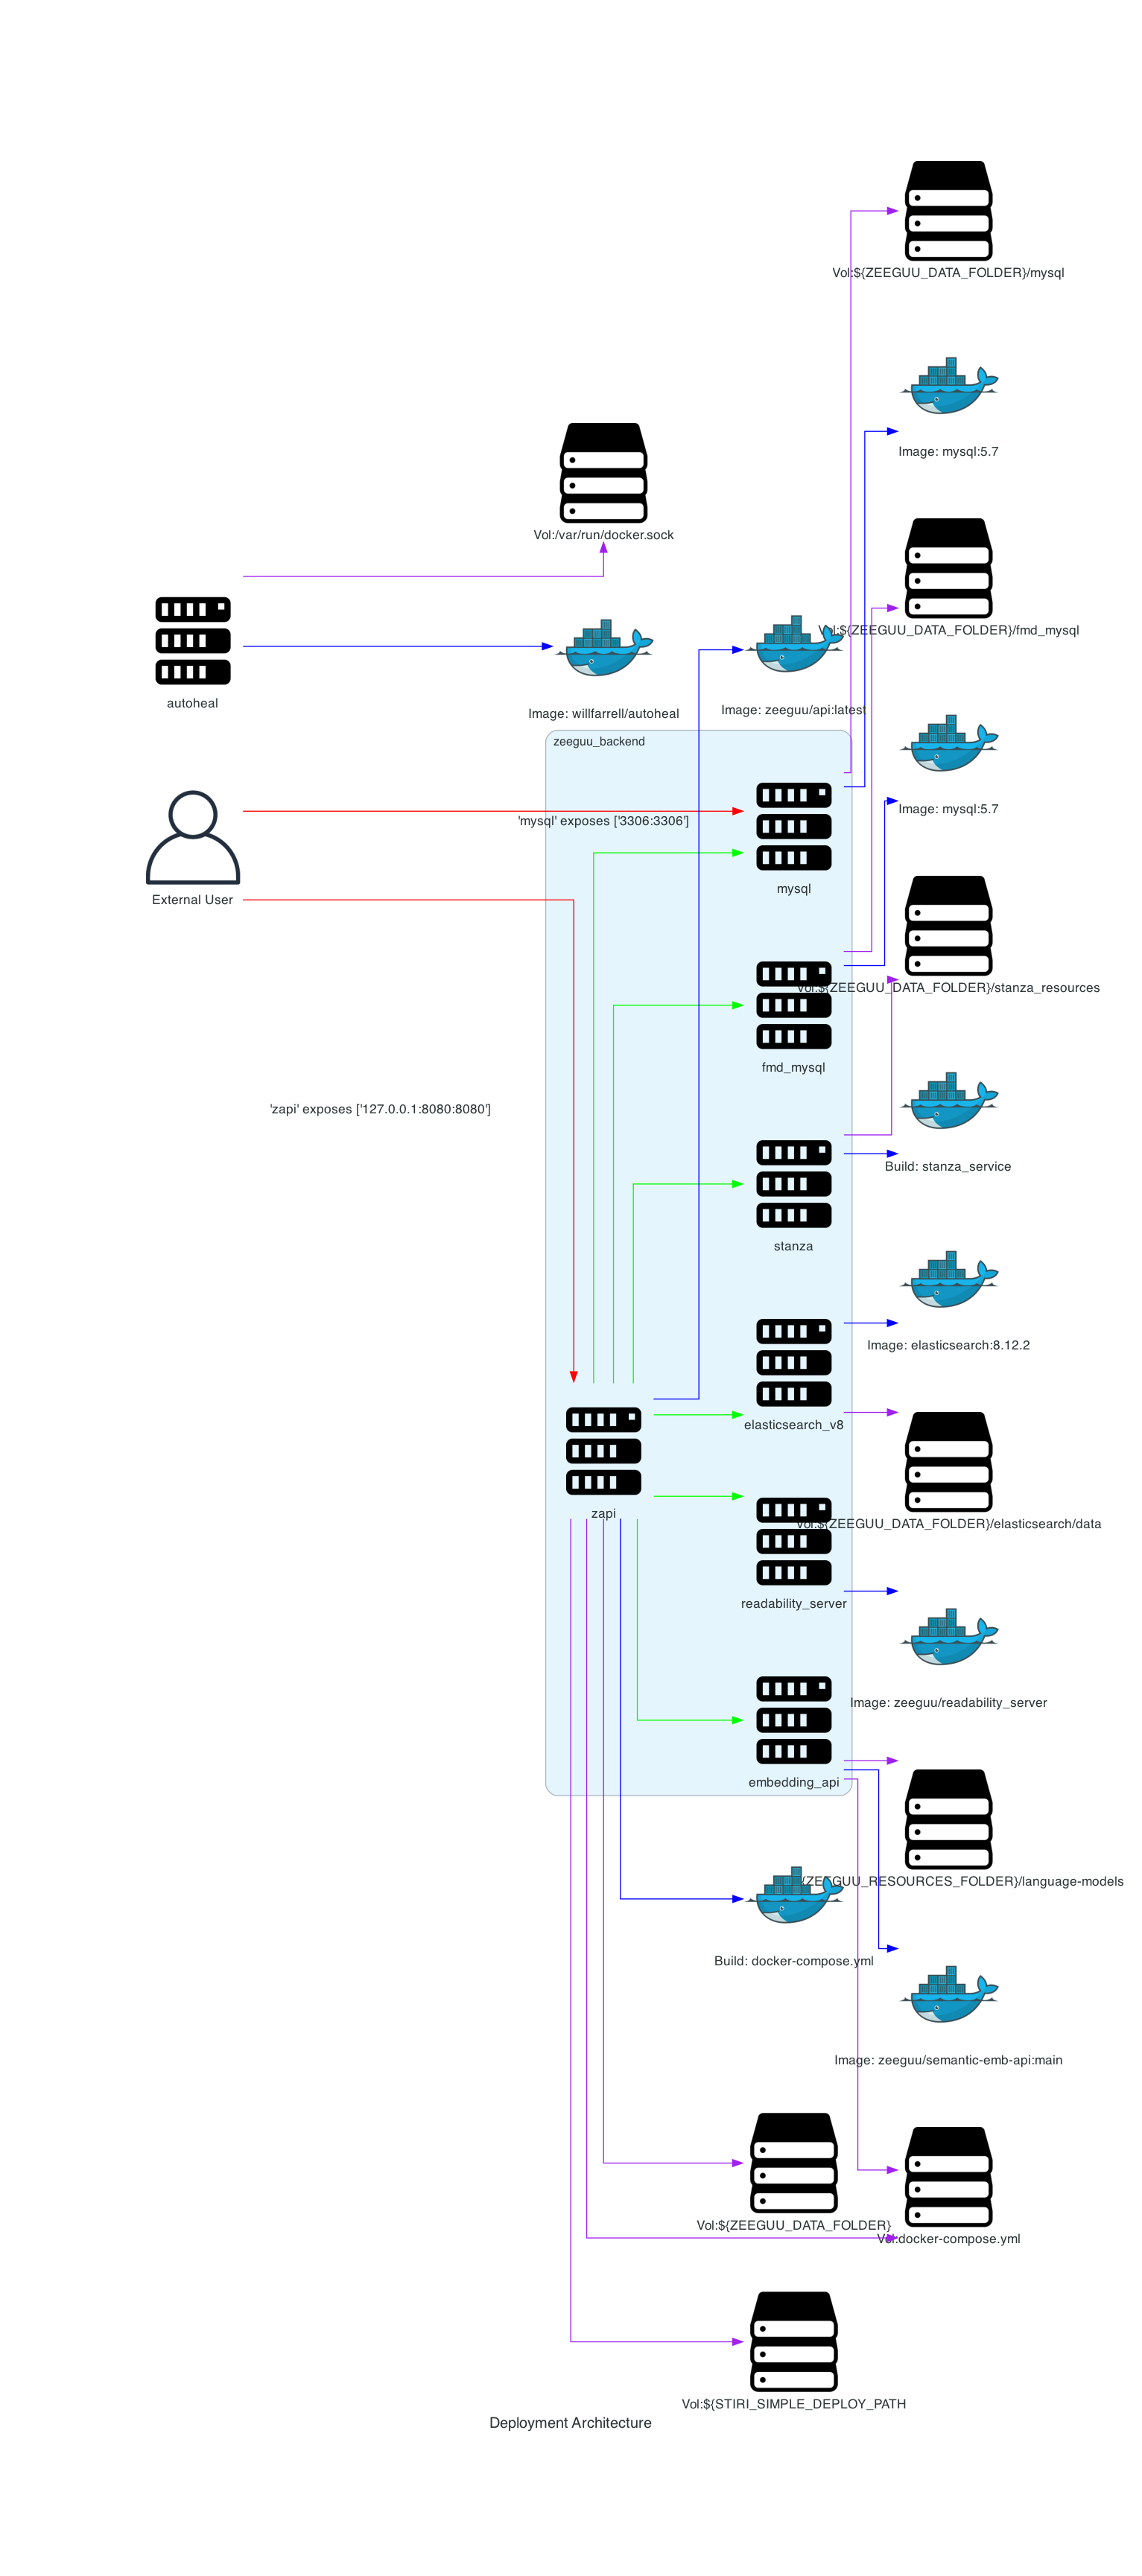

In [4]:
!{sys.executable} -m pip install diagrams --quiet

from diagrams import Cluster, Diagram, Edge
from diagrams.onprem.container import Docker
from diagrams.onprem.compute import Server
from diagrams.generic.storage import Storage
from diagrams.aws.general import User

def visualize_deployment_architecture(deployment_info, output_file="deployment_architecture.png", development=False):
    with Diagram("Deployment Architecture", show=False, filename=output_file):
        user = User("External User") #to visualize where the system is exposed to external users
        volumes = {}
        networks = {}
        services = {}
        images = {}

        for vol in deployment_info["volumes"]:
            volumes[vol] = Storage("Vol:" +vol)
        
        for net in deployment_info["networks"]:
            networks[net] = Cluster(net)

        for s_name, s_info in deployment_info["services"].items():
            if not development and s_info.get("is_dev", False):
                continue # skip dev/test services if we're not in development mode
            if s_info["networks"]: # if the service is connected to a network that we have identified, place it inside the cluster for that network
                net = s_info["networks"][0] # if the service is connected to multiple networks, we will just use the first one for visualization purposes (this is a simplification and may not capture all the nuances of the actual deployment architecture, but it should give us a good starting point for understanding the overall structure of the system)
                with networks[net]:
                    services[s_name] = Server(s_name)

                    for vol in s_info["volumes"]:
                        if vol in volumes:
                            services[s_name] >> Edge(color="purple") >> volumes[vol]
            else:
                services[s_name] = Server(s_name)

                for vol in s_info["volumes"]:
                    if vol in volumes:
                        services[s_name] >> Edge(color="purple") >> volumes[vol]

        for s_name, s_info in deployment_info["services"].items():
            if not development and s_info.get("is_dev", False):
                continue # skip dev/test services if we're not in development mode
            current_service = services[s_name]
            for dep in s_info.get("depends_on", []):
                if dep in services:
                    current_service >> Edge(color="green") >> services[dep]
                else:
                    print(f"Warning: Service {s_name} depends on {dep}, but {dep} is not defined as a service in the deployment info.")
            
            ports = s_info.get("ports", [])
            if ports:
                user >> Edge(label=f"\'{s_name}\' exposes {ports}", color="red") >> services[s_name]
            
            img = s_info.get("image", "")
            if img:
                images[img] = Docker("Image: " + img)
                services[s_name] >> Edge(color="blue") >> images[img]
            
            builds = s_info.get("build", "")
            if builds:
                for build in builds if isinstance(builds, set) else [builds]:
                    images[build] = Docker("Build: " + build)
                    services[s_name] >> Edge(color="blue") >> images[build]


    print(f"Deployment architecture diagram saved as {output_file}")

#Legend:
# - Purple edges represent the use of volumes by services 
# - Green edges represent dependencies between services (e.g. if service A depends on service B, there will be a green edge from A to B)
# - Red edges represent exposed ports to external users, including a label specifying which ports are exposed 
# - Blue edges represent the relationship between services and their images/builds
# - Services that are identified as dev/test services based on their names (e.g. containing "dev" or "test") can be optionally excluded from the diagram to focus on the production deployment architecture.


output_file = "graphs/deployment_architecture"
visualize_deployment_architecture(deployment_info, output_file, development=False)

# show the generated diagram in the notebook
from IPython.display import Image
Image(filename=output_file + ".png")



In the above diagram, all services of the compose files are shown with a Server-icon, images/build contexts are shown with a Docker-icon, and volumes are shown with a Storage-icon. 
The edges represent the dependencies between the services, images/build contexts, and volumes. 
This visualization allows us to see the overall structure of the deployment architecture and how the different services interact with each other through their dependencies on images/build contexts and volumes.